# Assignment 1: The AI Arcade - Inference & Search (Module 1)

## The Scenario
You are the Lead AI Engineer at *RetroMind Studios*, a company reviving classic board games with built-in digital AI opponents. Your current project is "The AI Arcade," featuring two classic games: **Mastermind** and **Peg Solitaire**.

Because these are perfectly constrained logical games with discrete rules, modern Deep Learning (which relies on probability and guessing) is the wrong tool for the job. You must build your agents using the absolute mathematical certainty of inference and search techniques.

For Mastermind, you will build an **Expert System** driven by Forward Chaining logic. For Peg Solitaire, you will build a **Pathfinding Agent** using Uninformed (BFS/DFS) and Informed (A*) Search algorithms.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geraldmc/unified-labs/blob/main/the_symbolic_architect/Assignment1-notebook.ipynb)

## Milestone 1: Set up

*Run this cell first. It provides the `MastermindEngine`, the game loop, and the Matplotlib visualization tools that will animate your AI's "Probability Heatmap" as it zeroes in on the answer.*

In [ ]:
# MILESTONE 1 SETUP - RUN THIS CELL FIRST
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output
import time
import itertools

COLORS = ['Red', 'Blue', 'Green', 'Yellow', 'Orange', 'Purple']
HEX_MAP = {'Red': '#FF4136', 'Blue': '#0074D9', 'Green': '#2ECC40',
           'Yellow': '#FFDC00', 'Orange': '#FF851B', 'Purple': '#B10DC9'}

class MastermindEngine:
    def __init__(self, secret_code, ai_player):
        self.secret_code = secret_code
        self.ai = ai_player
        self.turn = 1

    def calculate_feedback(self, guess, true_code):
        black_pegs, white_pegs = 0, 0
        guess_pool, true_pool = [], []

        for i in range(4):
            if guess[i] == true_code[i]:
                black_pegs += 1
            else:
                guess_pool.append(guess[i])
                true_pool.append(true_code[i])

        for c in guess_pool:
            if c in true_pool:
                white_pegs += 1
                true_pool.remove(c)

        return black_pegs, white_pegs

    def render_frame(self, guess, black, white):
        clear_output(wait=True)
        fig, (ax_board, ax_matrix) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [1, 2]})

        # --- DRAW TOP HALF (The Guess) ---
        ax_board.set_xlim(-1, 5)
        ax_board.set_ylim(-1, 2)
        ax_board.axis('off')
        ax_board.set_title(f"Turn {self.turn} | Hypotheses Remaining: {len(self.ai.possible_codes)}", fontsize=14, fontweight='bold')

        for i, color in enumerate(guess):
            circle = patches.Circle((i, 0.5), 0.4, color=HEX_MAP[color], ec="black")
            ax_board.add_patch(circle)

        ax_board.text(4, 0.5, f"{black} Black, {white} White", fontsize=12, va='center', fontweight='bold')

        # --- DRAW BOTTOM HALF (The Probability Heatmap) ---
        ax_matrix.set_xlim(-1, 4)
        ax_matrix.set_ylim(-1, 6)
        ax_matrix.axis('off')
        ax_matrix.set_title("AI Hypothesis Heatmap", fontsize=14, fontweight='bold')

        # Calculate frequencies to determine how bright to draw each circle
        total_hypotheses = len(self.ai.possible_codes)
        for slot in range(4):
            ax_matrix.text(slot, 5.5, f"Slot {slot}", ha='center', fontweight='bold')
            for c_idx, color in enumerate(COLORS):
                # Count how many remaining hypotheses have this color in this slot
                count = sum(1 for code in self.ai.possible_codes if code[slot] == color)
                probability = count / total_hypotheses if total_hypotheses > 0 else 0

                # Draw the circle with opacity based on probability!
                circle = patches.Circle((slot, 4.5 - c_idx), 0.3, color=HEX_MAP[color], alpha=probability)
                ax_matrix.add_patch(circle)

                if probability == 0:
                    ax_matrix.text(slot, 4.5 - c_idx, "X", color='red', ha='center', va='center', fontsize=20, alpha=0.5)

        plt.tight_layout()
        plt.show()
        time.sleep(3)

    def play(self):
        print("Starting AI Codebreaker Sequence...")
        time.sleep(1)

        while self.turn <= 10:
            guess = self.ai.generate_next_guess()
            black, white = self.calculate_feedback(guess, self.secret_code)

            # The AI processes the feedback BEFORE rendering so the heatmap updates instantly
            self.ai.process_feedback(guess, black, white)
            self.render_frame(guess, black, white)

            if black == 4:
                print(f"\nWIN! The AI cracked the code in {self.turn} turns.")
                return self.turn
            self.turn += 1

        print("\nFAILURE. The AI ran out of turns.")
        return self.turn

print("Graphics & Game Engine successfully loaded.")

## Milestone 1: The Codebreaker (Constraint Satisfaction)
**Objective:** You will code an AI agent to solve the **Mastermind** game.

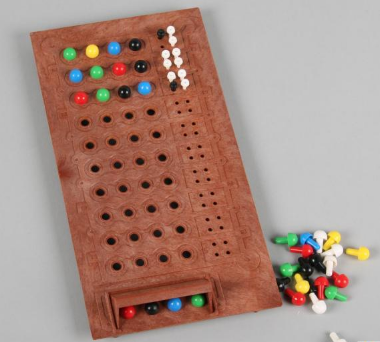

In Mastermind, a human "Codemaker" creates a secret 4-color code. The AI "Codebreaker" must guess the code. Because the feedback in Mastermind (Black and White pegs) is "entangled" (meaning the AI knows a color is right, but not *which* slot it belongs to), simple independent rules will fail.

Instead, you will build a **Constraint Satisfaction Engine**. The AI will start with a "Hypothesis Space" of all 1,296 possible codes. After every guess, the AI will use the feedback to apply **The Consistency Rule**: *If a hypothetical code were the true answer, it MUST yield the exact same feedback against my guess as the real code did.* By simulating the feedback for every remaining hypothesis, the AI will mathematically prune the state space until only the truth remains.

### The Architect's Blueprint
*Write the logic inside your `MastermindAI` class to prune the Hypothesis Space using Constraint Satisfaction.*

* **1. Initialize the AI:** Inside `__init__`, create `self.possible_codes`. Use `itertools.product(COLORS, repeat=4)` to generate all 1,296 possible 4-color combinations and store them as a `list`.
* **2. Simulate the Feedback:** Write the `simulate_feedback(guess, hypothetical_code)` method.
    * Calculate exact matches (Black Pegs) by checking if `guess[i] == hypothetical_code[i]`.
    * Calculate right-color-wrong-spot (White Pegs). *Hint: Be careful not to double-count pegs that were already counted as Black! You may need to create temporary lists of the unmatched colors.*
* **3. The Consistency Rule:** Write `process_feedback(guess, actual_black, actual_white)`.
    * Create an empty list called `valid_hypotheses`.
    * Loop through every `hypo_code` currently inside `self.possible_codes`.
    * Call your `simulate_feedback` method to see what feedback the `hypo_code` *would* give.
    * If the simulated feedback perfectly matches the actual feedback, append it to `valid_hypotheses`.
    * Finally, overwrite `self.possible_codes` with your new, filtered list.
* **4. Action:** Write `generate_next_guess()`. Simply return the first item in your `self.possible_codes` list!



In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness

In [ ]:
# MILESTONE 1 TEST HARNESS
ai_player = MastermindAI()
game = MastermindEngine(secret_code=['Blue', 'Purple', 'Green', 'Yellow'], ai_player=ai_player)
turns_taken = game.play()

assert turns_taken <= 6, "Failure: A Constraint Satisfaction algorithm should never take more than 6 turns."
print("SUCCESS! The Mastermind AI successfully pruned the state space.")

### Architect's Audit (Milestone 1)

1. **State Space Reduction:** Look at the printout for "Hypotheses Remaining" after Turn 1. How many possibilities were eliminated by a single guess? Why is this Constraint Satisfaction approach vastly superior to blind guessing?

ENTER YOUR ANSWERS HERE

## Milestone 2: Set Up

*Run this cell to load the `PegBoard` class, the `get_valid_moves(state)` function, the `apply_move(state, move)` function, and the Matplotlib animation engine `animate_solution_path(path)`.*

In [ ]:
# MILESTONE 2 SETUP - RUN THIS CELL FIRST
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output
import time
from collections import deque

# The 15 valid jump combinations on a triangular board (start, jump_over, land)
VALID_JUMPS = [
    (0, 1, 3), (0, 2, 5), (1, 3, 6), (1, 4, 8), (2, 4, 7), (2, 5, 9),
    (3, 1, 0), (3, 4, 5), (3, 6, 10), (3, 7, 12), (4, 7, 11), (4, 8, 13),
    (5, 2, 0), (5, 4, 3), (5, 8, 12), (5, 9, 14), (6, 3, 1), (6, 7, 8),
    (7, 4, 2), (7, 8, 9), (8, 4, 1), (8, 7, 6), (9, 5, 2), (9, 8, 7),
    (10, 6, 3), (10, 11, 12), (11, 7, 4), (11, 12, 13), (12, 7, 3),
    (12, 8, 5), (12, 11, 10), (12, 13, 14), (13, 8, 4), (13, 12, 11),
    (14, 9, 5), (14, 13, 12)
]

# Physical coordinates for drawing the triangle
COORDS = {
    0: (2, 4),
    1: (1.5, 3), 2: (2.5, 3),
    3: (1, 2), 4: (2, 2), 5: (3, 2),
    6: (0.5, 1), 7: (1.5, 1), 8: (2.5, 1), 9: (3.5, 1),
    10: (0, 0), 11: (1, 0), 12: (2, 0), 13: (3, 0), 14: (4, 0)
}

class PegBoard:
    @staticmethod
    def get_initial_state(empty_hole=0):
        """Returns a tuple of 15 booleans. True = Peg, False = Empty."""
        return tuple(False if i == empty_hole else True for i in range(15))

    @staticmethod
    def get_valid_moves(state):
        """Returns a list of valid (start, jump_over, land) tuples for the current state."""
        moves = []
        for start, over, land in VALID_JUMPS:
            if state[start] and state[over] and not state[land]:
                moves.append((start, over, land))
        return moves

    @staticmethod
    def apply_move(state, move):
        """Returns a NEW state tuple after applying the jump."""
        start, over, land = move
        new_state = list(state)
        new_state[start] = False  # The jumping peg leaves
        new_state[over] = False   # The jumped peg is removed
        new_state[land] = True    # The jumping peg lands
        return tuple(new_state)

def animate_solution_path(initial_state, path):
    """Draws the board frame-by-frame to visualize the AI's solution."""
    current_state = initial_state

    for step, move in enumerate([None] + path):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, 4.5)
        ax.set_ylim(-0.5, 4.5)
        ax.axis('off')

        if move:
            ax.set_title(f"Step {step}: Jump {move[0]} over {move[1]} to {move[2]}", fontsize=14)
            current_state = PegBoard.apply_move(current_state, move)
        else:
            ax.set_title("Initial State", fontsize=14)

        for i in range(15):
            x, y = COORDS[i]
            # Draw the hole
            ax.add_patch(patches.Circle((x, y), 0.2, color='black', fill=False, lw=2))
            # Draw the peg if it exists
            if current_state[i]:
                ax.add_patch(patches.Circle((x, y), 0.15, color='#0074D9'))
            # Label the hole
            ax.text(x, y - 0.3, str(i), ha='center', fontsize=10)

        plt.show()
        time.sleep(1)

print("Peg Board Engine successfully loaded.")

## Milestone 2: The Peg Board (Uninformed Search)
**Objective:** You are now building the AI for **Triangular Peg Solitaire** (the classic Cracker Barrel game). The goal is to jump pegs over each other, removing the jumped peg, until only 1 peg remains.

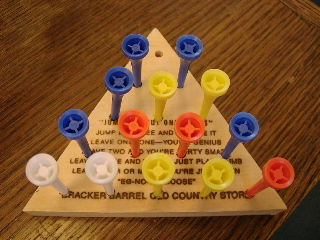

You must define the problem mathematically as a State Space graph. Then, you will implement two Uninformed Search algorithms (**Breadth-First Search (BFS)** and **Depth-First Search (DFS)**) to find a winning sequence of jumps.

### The Architect's Blueprint
*Implement `bfs_solve(start_state)` and `dfs_solve(start_state)`. You must use the provided `PegBoard.get_valid_moves(state)` and `PegBoard.apply_move(state, move)` functions.*

* **1. The Data Structures:** * For BFS, initialize a `deque()` to act as your Queue (FIFO).
    * For DFS, initialize a standard Python `list()` to act as your Stack (LIFO).
    * For both, initialize a `visited` set to track explored board states so you don't loop infinitely.
* **2. The State Representation:** A node in your frontier should be a tuple containing `(current_board_state, path_of_moves_taken_so_far)`. Push the initial state and an empty path list `[]` into your Frontier.
* **3. The Search Loop:** While the Frontier is not empty:
    * Pop the current node.
    * Check if it is a goal state! (Hint: A goal state is a tuple that contains exactly one `True` value. You can check this with `sum(current_state) == 1`). If it is the goal, return `(path, nodes_expanded)`.
    * If not, mark the state as visited.
    * Use `PegBoard.get_valid_moves` to get children. For each child move, use `PegBoard.apply_move` to generate the new state.
    * Append the `(new_state, new_path)` to your Frontier.
* **4. Tracking Metrics:** Create a counter variable `nodes_expanded` that increments every time you pop a node off the frontier. Return this number alongside your path so we can compare efficiency!


In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness

In [ ]:
# MILESTONE 2 TEST HARNESS
initial_board = PegBoard.get_initial_state(empty_hole=0)

print("Running Breadth-First Search (BFS)...")
bfs_path, bfs_nodes = bfs_solve(initial_board)

print("Running Depth-First Search (DFS)...")
dfs_path, dfs_nodes = dfs_solve(initial_board)

print(f"\n--- Search Metrics ---")
print(f"BFS expanded {bfs_nodes} states.")
print(f"DFS expanded {dfs_nodes} states.")

assert len(bfs_path) == 13, "Failure: A valid solution must contain exactly 13 jumps."
assert len(dfs_path) == 13, "Failure: A valid solution must contain exactly 13 jumps."

In [ ]:
# Animate the winning DFS path!
animate_solution_path(initial_board, dfs_path)

### Architect's Audit (Milestone 2)

1. **State Space Explosion:** Look at your `nodes_expanded` printouts. Explain why BFS explored drastically more nodes than DFS in this specific game. Why is memory usage a massive concern for BFS?

ENTER YOUR ANSWERS HERE

## Milestone 3: Set Up

Run this cell first

In [ ]:
# MILESTONE 3 SETUP - RUN THIS CELL FIRST
import heapq
print("Priority Queue library loaded. Ready for A* Search.")

## Milestone 3: The Pathfinder (Informed Search & A*)
**Objective:** BFS requires too much memory, and DFS relies on blind luck to dive down the correct path. You need an "Informed Search." You will design a custom heuristic $h(n)$ and implement the **A* Search Algorithm**.

In Triangular Peg Solitaire, every valid winning sequence is exactly 13 jumps long. Therefore, A* isn't trying to find a *shorter* path; it is trying to intelligently guess *which* branches are dead ends so it can find the winning path while exploring drastically fewer nodes than BFS.

### The Architect's Blueprint
*Implement `heuristic(state)` and `a_star_solve(start_state)`.*

* **1. Design a Custom Heuristic:** Write the `heuristic(state)` function.
    * *The Baseline:* The simplest estimate of remaining moves is just `sum(state) - 1` (the number of pegs remaining to be jumped).
    * *The Trap:* Because every jump costs 1, and every jump removes 1 peg, $f(n) = g(n) + h(n)$ will equal 13 for every single valid path! This provides no priority, turning A* back into a blind BFS.
    * *The Fix:* You must invent a custom penalty or bonus system to make your heuristic *informed*. Think about the geometry of the board: what makes a board state "bad" or likely to be a dead end? *(Hint: You can brainstorm heuristic ideas with your AI Assistant!)*
* **2. Implement A\*:** Write `a_star_solve(start_state)`.
    * Initialize your `frontier` as a list, and push a tuple into it using `heapq.heappush(frontier, (f_score, g_score, current_state, path))`.
* **3. The Search Loop:** * Pop the node with the lowest $f(n)$ using `heapq.heappop(frontier)`.
    * Check for the goal state (`sum(state) == 1`).
    * Generate children. For each child, calculate the new $g(n)$ (which is `current_g + 1`) and the new $h(n)$ using your custom heuristic.
    * Calculate $f(n) = g(n) + h(n)$.
    * Push the new child into the frontier.

In [ ]:
# ENTER YOUR CODE HERE

### The Test Harness

In [ ]:
# MILESTONE 3 TEST HARNESS
print("Running A* Search...")
astar_path, astar_nodes = a_star_solve(initial_board)

print(f"\n--- Final Search Metrics ---")
print(f"BFS expanded: {bfs_nodes} states.")
print(f"DFS expanded: {dfs_nodes} states.")
print(f"A* expanded:  {astar_nodes} states.")

assert len(astar_path) == 13, "Failure: A valid solution must contain exactly 13 jumps."
assert astar_nodes < bfs_nodes, "Failure: Your A* heuristic is not informed enough; it explored more nodes than blind BFS!"

In [ ]:
animate_solution_path(initial_board, astar_path)

### Architect's Audit (Milestone 3)

1. **The Custom Heuristic:** Explain the exact mathematical logic inside your `heuristic(state)` function. How did you (or your AI assistant) decide which board states to penalize or reward?
2. **Admissibility:** Based on Lecture 1.8, explain what it means for a heuristic to be "Admissible." Does your custom heuristic risk being inadmissible?

ENTER YOUR ANSWERS HERE

## The Sprint Review (Video Submission & Audit Summary)

To complete the Assignment, you must submit your final Colab Notebook and record a **3-to-5 minute maximum** video presentation of your screen.

Assume your audience contains both technical engineering managers and non-technical product executives of *RetroMind Studios*.

**Your presentation must address the following prompts using visual evidence from your Colab notebook:**

1. **The "Detective Alibi" (Mastermind):** Show the visual animation of your Mastermind Probability Heatmap. Explain to the executives how the **Consistency Rule** works. In your own words, explain why simulating hypothetical codes and checking if they mathematically contradict the real-world feedback is a foolproof way to crack the code without getting trapped in an infinite loop.
2. **The Power of Rule-based AI vs. Modern LLMs:** Why was a strict, rule-based Constraint Satisfaction system the perfect architectural choice for Mastermind? Contrast this with why a modern Large Language Model (like ChatGPT) might struggle or "hallucinate" while playing a perfectly constrained math game.
4. **The Custom Heuristic (A\*):** Show the printed `nodes_expanded` metrics for BFS vs. DFS vs. A*. Explain how A* solved the memory problems of BFS. Describe the specific custom heuristic $h(n)$ you engineered. Explain the terms "Admissible" and "Consistent," and mathematically justify whether your custom heuristic is admissible or if it prioritizes speed over guaranteed optimality.